# Parkinson Disease Early Detection
in this project, we will use machine learning algorithms to detect parkinson disease.
<b> in the begining, </b> we will install and import necessary modules and read our dataset.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [51]:
# import modules
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.utils import shuffle
import librosa

In [52]:
# Specify the file path
file_path = "/content/drive/MyDrive/multimodal project/datasets/voice/Parkinsson disease.csv"

# Read data from the CSV file
data = pd.read_csv(file_path)

In [53]:
# show the first five samples
data.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


# Data Distribution
we will visualize data distribution, this proess help us to understand dataset deeply.


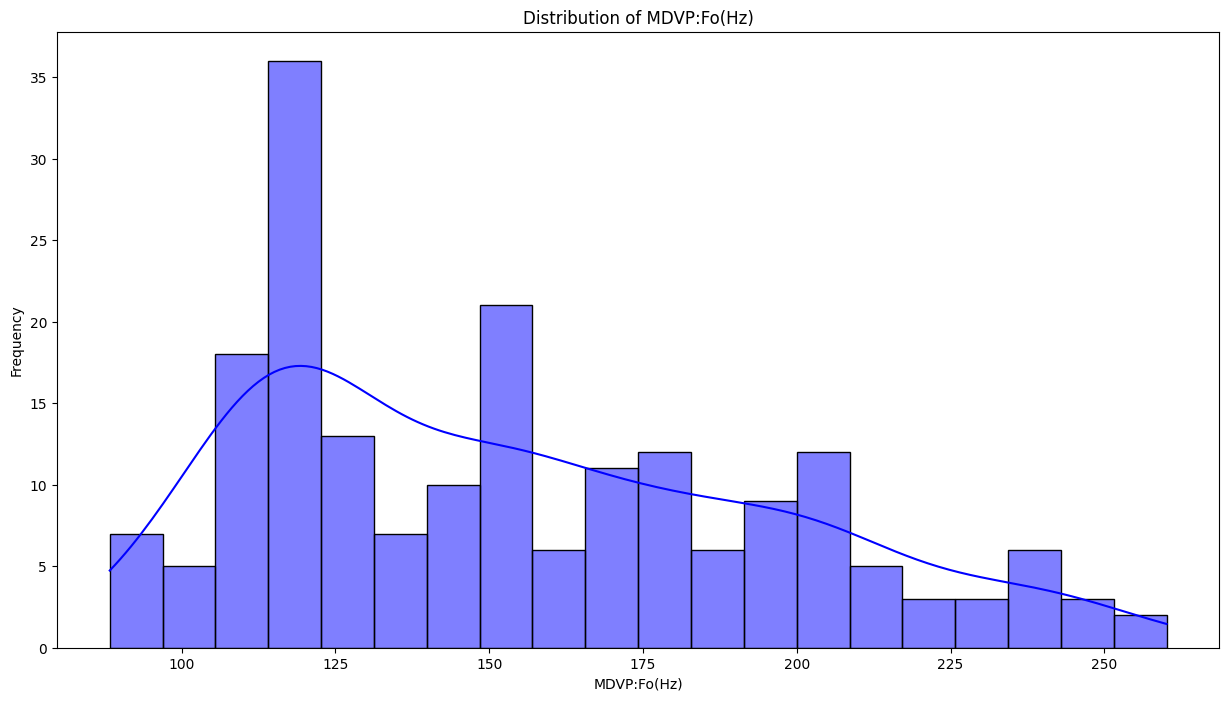

In [ ]:
plt.figure(figsize=(15, 8))

# Plot the distribution of 'MDVP:Fo(Hz)'
sns.histplot(data['MDVP:Fo(Hz)'], bins=20, kde=True, color='blue')

# Set the title and labels
plt.title('Distribution of MDVP:Fo(Hz)')
plt.xlabel('MDVP:Fo(Hz)')
plt.ylabel('Frequency')

# Show the plot
plt.show()

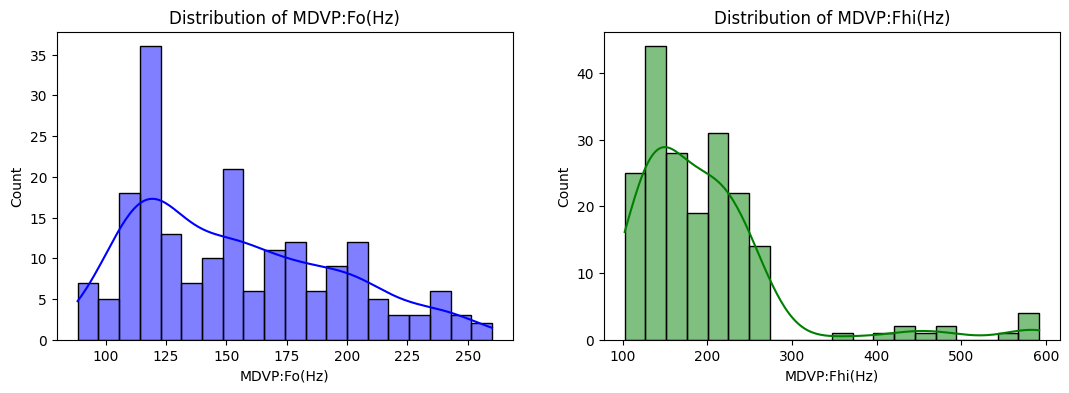

In [ ]:
plt.figure(figsize=(20, 10))
plt.subplots_adjust(hspace=0.5)

# Plot multiple distributions
plt.subplot(2, 3, 1)
sns.histplot(data['MDVP:Fo(Hz)'], bins=20, kde=True, color='blue')
plt.title('Distribution of MDVP:Fo(Hz)')

plt.subplot(2, 3, 2)
sns.histplot(data['MDVP:Fhi(Hz)'], bins=20, kde=True, color='green')
plt.title('Distribution of MDVP:Fhi(Hz)')

# Add more subplots for other variables as needed

# Show the plot
plt.show()


<Figure size 1500x800 with 0 Axes>

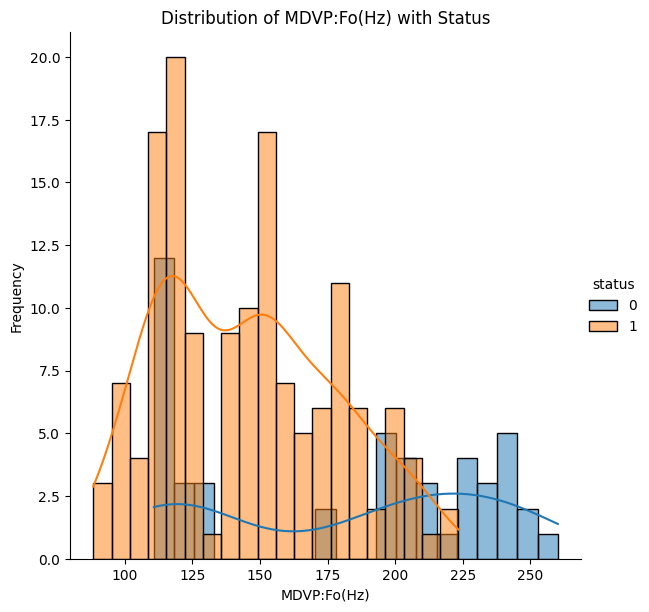

In [ ]:
plt.figure(figsize=(15, 8))

# Create a FacetGrid with 'status' as hue
g = sns.FacetGrid(data, hue='status', height=6)
g.map(sns.histplot, 'MDVP:Fo(Hz)', bins=20, kde=True, alpha=0.5)

# Set the title and labels
plt.title('Distribution of MDVP:Fo(Hz) with Status')
plt.xlabel('MDVP:Fo(Hz)')
plt.ylabel('Frequency')

# Add a legend
g.add_legend()

# Show the plot
plt.show()


<Figure size 1500x1000 with 0 Axes>

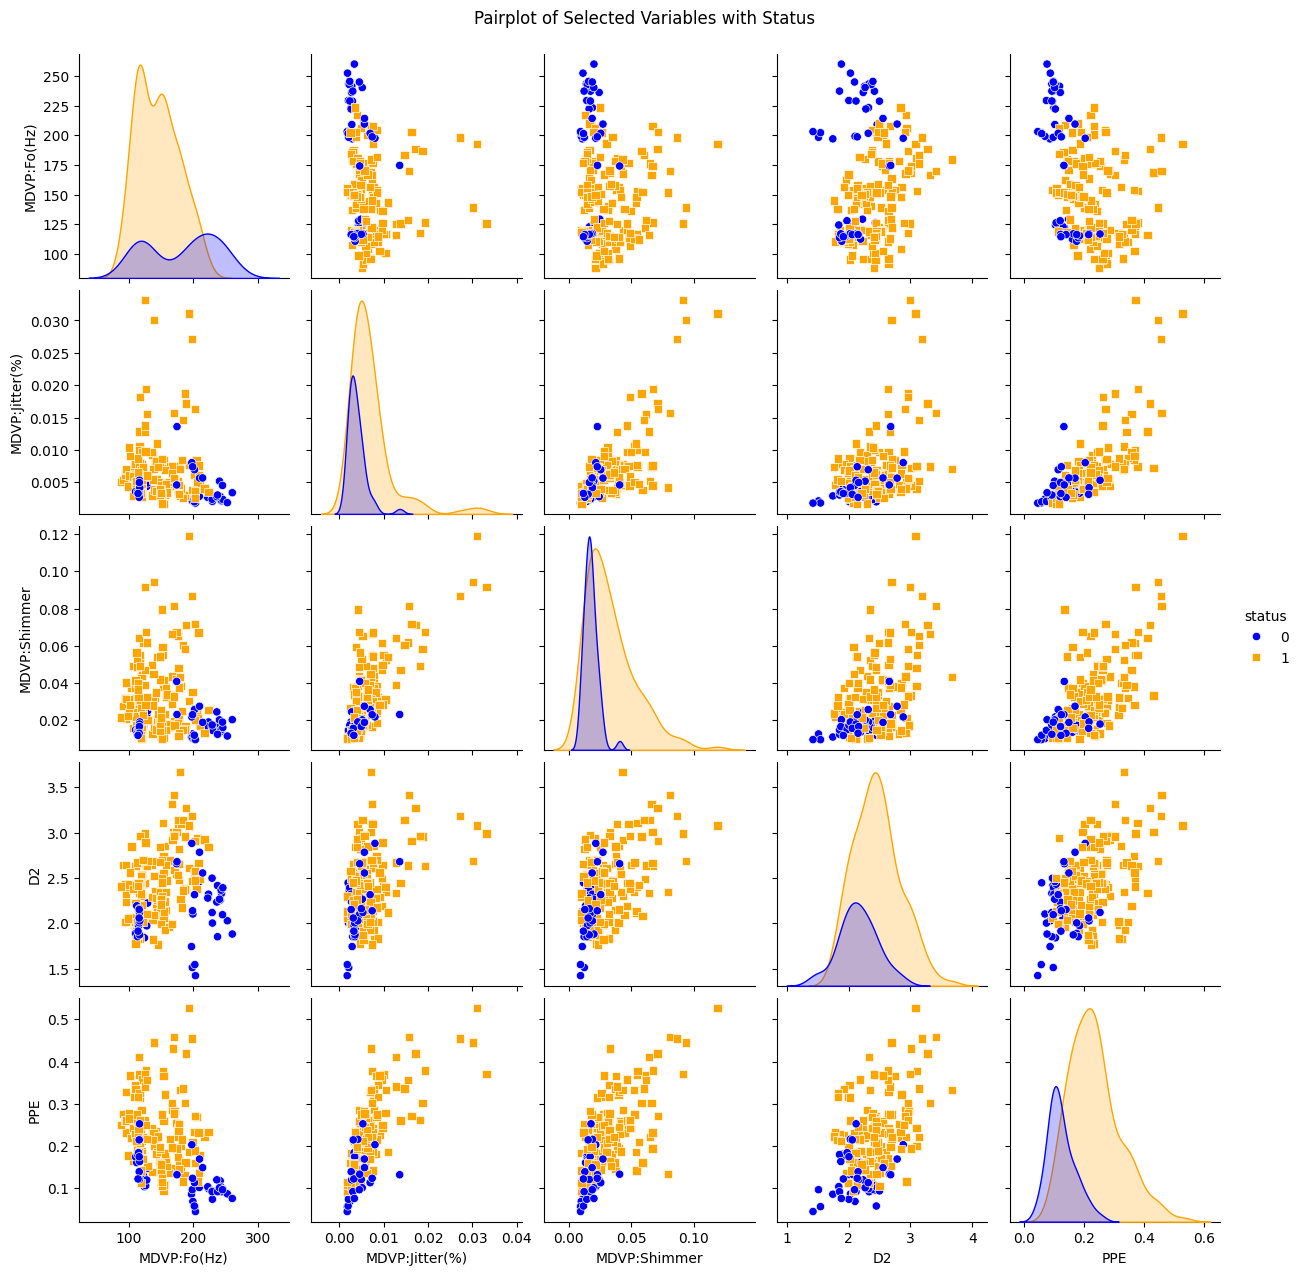

In [ ]:
# Select relevant variables
selected_vars = ['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Shimmer', 'D2', 'PPE', 'status']

# Create a DataFrame with selected variables
selected_data = data[selected_vars]

# Create a pairplot
plt.figure(figsize=(15, 10))
sns.pairplot(selected_data, hue='status', diag_kind='kde', markers=['o', 's'], palette={0: 'blue', 1: 'orange'})

# Set the title
plt.suptitle('Pairplot of Selected Variables with Status', y=1.02)

# Show the plot
plt.show()

# Data Cleaning and Exploration
we will use pandas to clean our data and Extract important information from the features we have and knowing the types of data contained in it so that we can transform the data into the appropriate form for machine learning algorithms.

In [54]:
# show information about dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [55]:
# show statistical description for dataset
data.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [56]:
# detect the number of missing values in each colum
missing_values = data.isnull().sum()
missing_values

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

In [57]:
data['status'].value_counts()

status
1    147
0     48
Name: count, dtype: int64

In [58]:
# Drop unnecessary column
data = data.drop('name', axis=1)

# Calculate z-score for each feature
z_scores = (data - data.mean()) / data.std()

# Remove outliers using the standard threshold = 3
data = data[(z_scores < 3).all(axis=1)]

# Check that the number of samples equals 181 and the number of features equals 13
print("Number of samples after removing outliers:", data.shape[0])
print("Number of features after removing outliers:", data.shape[1])

Number of samples after removing outliers: 181
Number of features after removing outliers: 23


In [59]:
# Calculate the correlation coefficient between each pair of features
correlation_matrix = data.corr()

# Identify columns with strong correlations (more than 0.8 or less than -0.8)
strong_correlation = np.where(np.abs(correlation_matrix) > 0.8)

# Drop the column if it has a strong correlation with any other column
for col1, col2 in zip(*strong_correlation):
    if col1 != col2 and col1 < col2:
        if col1 in data.columns and col2 in data.columns:
            data = data.drop(data.columns[col2], axis=1)

In [60]:
data.shape

(181, 23)

# Balancing the data
We noticed that the data we have is unbalanced, and in order for the result that we will obtain to be fair and so that the algorithm is not biased, we will balance the data using one of the data augmentation techniques so that the number of patient samples becomes equal to the number of healthy people’s samples.

In [114]:
# Shuffle the dataset
data = shuffle(data, random_state=42)

In [115]:
# Separate features (X) and target variable (y)
X = data.drop('status', axis=1)
y = data['status']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("x_train shape is: {}".format(X_train.shape))
print("y_train shape is: {}".format(y_train.shape))
print("X_test shape is: {}".format(X_test.shape))
print("y_test shape is: {}".format(y_test.shape))

x_train shape is: (126, 22)
y_train shape is: (126,)
X_test shape is: (55, 22)
y_test shape is: (55,)


In [116]:
# Display class distribution before balancing for training set
print("Class distribution before balancing for training set:")
print(y_train.value_counts())

Class distribution before balancing for training set:
status
1    95
0    31
Name: count, dtype: int64


In [117]:
# Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Display class distribution after balancing for training set
print("\nClass distribution after balancing for training set:")
y_train_balanced.value_counts()


Class distribution after balancing for training set:


status
1    95
0    95
Name: count, dtype: int64

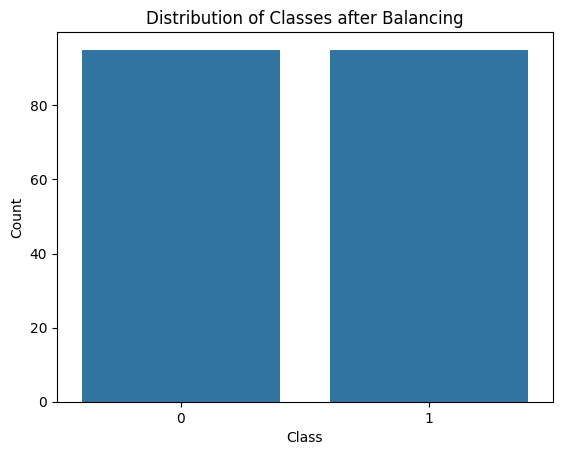

In [118]:
# Calculate class distribution after balancing
class_distribution = pd.Series(y_train_balanced).value_counts()

# Plot the class distribution
sns.barplot(x=class_distribution.index, y=class_distribution.values)
plt.title('Distribution of Classes after Balancing')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [119]:
X_train_balanced.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,177.876,192.921,168.013,0.00411,0.00002,0.00233,0.00241,0.00700,0.02126,0.189,...,0.01612,0.03463,0.00586,23.216,0.360148,0.778834,-6.149653,0.218037,2.477082,0.165827
1,127.930,138.752,112.173,0.00605,0.00005,0.00321,0.00318,0.00962,0.03235,0.339,...,0.03105,0.04079,0.02663,19.651,0.654945,0.675865,-5.498456,0.234196,2.103014,0.216638
2,156.405,189.398,142.822,0.00768,0.00005,0.00372,0.00399,0.01116,0.03995,0.348,...,0.04310,0.05164,0.03365,17.153,0.649554,0.686080,-4.554466,0.340176,2.856676,0.322111
3,110.568,125.394,106.821,0.00462,0.00004,0.00226,0.00280,0.00677,0.02199,0.197,...,0.01636,0.03852,0.00420,25.820,0.429484,0.816340,-5.391029,0.250572,1.777901,0.232744
4,260.105,264.919,237.303,0.00339,0.00001,0.00205,0.00186,0.00616,0.02030,0.197,...,0.01367,0.03557,0.00910,21.083,0.440988,0.628058,-7.517934,0.160414,1.881767,0.075587


# feature selection
Here we will use one of the feature selection techniques to choose a number of features that will be input to the machine learning algorithms, as we will not train the algorithm on all the features in the dataset, but rather we will choose the best of these features.

In [120]:
# Selecting the features based on their names
selected_features = [
    'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
    'MDVP:Shimmer', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2'
]

# Filter the training dataset to include only the selected features
X_train = X_train_balanced[selected_features]

# Filter the testing dataset to include only the selected features
X_test = X_test[selected_features]

# Scaling
We will use scaling techniques to make the features in the same field. This step is very important and will make the features equally important in the model. the we will split our data to train and test (80% for training and 20% for testing).

In [121]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_train = scaler.fit_transform(X_train)

X_test = scaler.fit_transform(X_test)

# Reduce data dimensionality
we will reduce the number of features using PCA algorithm.

In [122]:
# Step 2: Compute the covariance matrix
cov_matrix = np.cov(X_train.T)

# Step 3: Compute the eigenvectors and eigenvalues of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Step 4: Select the top eigenvectors based on the explained variance
total_variance = sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance
explained_variance_ratio_cumsum = np.cumsum(explained_variance_ratio)

# Choose the number of components to retain based on the explained variance ratio
n_components = 9  # You can adjust this based on the desired explained variance

# Step 5: Transform the original dataset into the new feature space
pca = PCA(n_components=n_components)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)


In [123]:
# Get the names of the selected features
selected_feature_indices = pca.components_

# Assuming you have a list of feature names, you can use the selected indices to get the names
selected_features = [selected_features[i] for i in range(n_components)]

In [124]:
selected_features

['MDVP:Fo(Hz)',
 'MDVP:Fhi(Hz)',
 'MDVP:Flo(Hz)',
 'MDVP:Jitter(%)',
 'MDVP:Shimmer',
 'NHR',
 'HNR',
 'RPDE',
 'DFA']

in each algorithm we will train and evaluate the model and visualize accuracy and error for test data in each it and draw confusion matrix for testing data.
# Random Forest Algorithm


In [125]:
# Initialize the Random Forest model
random_forest_model = RandomForestClassifier(random_state=42)

# Train the Random Forest model
random_forest_model.fit(X_train, y_train_balanced)

RandomForestClassifier(random_state=42)

Accuracy (train): 1.0
Precision (train): 1.0
Recall (train): 1.0
F1 Score (train): 1.0


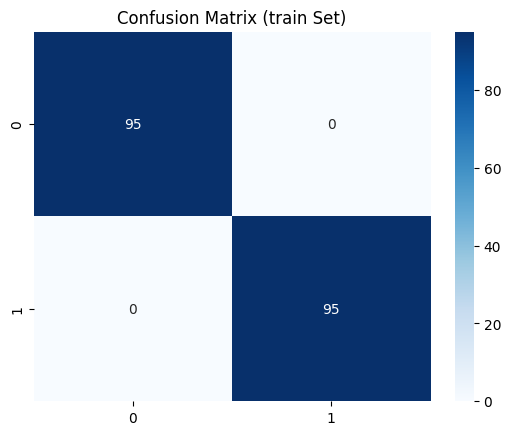

In [126]:
# Predict the labels for the training set
y_pred_test = random_forest_model.predict(X_train)

# Calculate accuracy, precision, recall, and f1_score
accuracy_test_rf = accuracy_score(y_train_balanced, y_pred_test)
precision_test = precision_score(y_train_balanced, y_pred_test)
recall_test = recall_score(y_train_balanced, y_pred_test)
f1_test = f1_score(y_train_balanced, y_pred_test)

# Display the calculated metrics
print(f'Accuracy (train): {accuracy_test_rf}')
print(f'Precision (train): {precision_test}')
print(f'Recall (train): {recall_test}')
print(f'F1 Score (train): {f1_test}')

# Plot confusion matrix
conf_matrix_test = confusion_matrix(y_train_balanced, y_pred_test)
sns.heatmap(conf_matrix_test, annot=True, fmt='g', cmap='Blues')
plt.title('Confusion Matrix (train Set)')
plt.show()

Accuracy (Test): 0.8363636363636363
Precision (Test): 0.9428571428571428
Recall (Test): 0.825
F1 Score (Test): 0.88


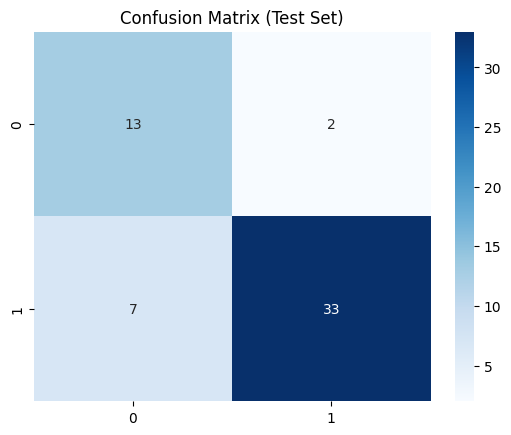

In [127]:
# Predict the labels for the test set
y_pred_test = random_forest_model.predict(X_test)

# Calculate accuracy, precision, recall, and f1_score
accuracy_test_rf = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

# Display the calculated metrics
print(f'Accuracy (Test): {accuracy_test_rf}')
print(f'Precision (Test): {precision_test}')
print(f'Recall (Test): {recall_test}')
print(f'F1 Score (Test): {f1_test}')

# Plot confusion matrix
conf_matrix_test = confusion_matrix(y_test, y_pred_test)
sns.heatmap(conf_matrix_test, annot=True, fmt='g', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# with cross validation

In [128]:
from sklearn.model_selection import LeaveOneOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import joblib

In [129]:
# Combine training and testing data
X_combined = np.concatenate((X_train, X_test), axis=0)
y_combined = np.concatenate((y_train_balanced, y_test), axis=0)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_combined_scaled = scaler.fit_transform(X_combined)

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier()

# Define Leave-One-Subject-Out Cross-Validation
loo = LeaveOneOut()

# Initialize a list to store the accuracy scores
train_accuracy_scores = []
test_accuracy_scores = []

# Perform Leave-One-Subject-Out Cross-Validation
for train_index, test_index in loo.split(X_combined_scaled):
    X_train_loo, X_test_loo = X_combined_scaled[train_index], X_combined_scaled[test_index]
    y_train_loo, y_test_loo = y_combined[train_index], y_combined[test_index]

    # Fit the Random Forest Classifier to the training data
    rf_classifier.fit(X_train_loo, y_train_loo)

    # Predict the labels for the training data
    y_train_pred_loo = rf_classifier.predict(X_train_loo)

    # Calculate the training accuracy score for this iteration
    train_accuracy = accuracy_score(y_train_loo, y_train_pred_loo)
    train_accuracy_scores.append(train_accuracy)

    # Predict the labels for the test data
    y_test_pred_loo = rf_classifier.predict(X_test_loo)

    # Calculate the test accuracy score for this iteration
    test_accuracy = accuracy_score(y_test_loo, y_test_pred_loo)
    test_accuracy_scores.append(test_accuracy)

# Calculate the average training and testing accuracy across all iterations
average_train_accuracy = sum(train_accuracy_scores) / len(train_accuracy_scores)
average_test_accuracy = sum(test_accuracy_scores) / len(test_accuracy_scores)

# Print the average training and testing accuracy
print("Average Training Accuracy:", average_train_accuracy)
print("Average Testing Accuracy:", average_test_accuracy)


Average Training Accuracy: 0.9999832719973235
Average Testing Accuracy: 0.9102040816326531


In [130]:
# Train the model on the entire dataset
# rf_classifier.fit(X_combined_scaled, y_combined)
rf_classifier.fit(X_train, y_train_balanced)

X_train, y_train_balanced
# Save the trained model to a file
joblib.dump(rf_classifier, '/content/drive/MyDrive/multimodal project/models/voice_modell.pkl')


['/content/drive/MyDrive/multimodal project/models/voice_modell.pkl']

## Using the model

In [131]:
import librosa
import numpy as np
from sklearn.preprocessing import StandardScaler
from IPython.display import Audio, display
import joblib

In [132]:
def play_audio(audio_file_path):
    display(Audio(audio_file_path, autoplay=True))

In [133]:
def predict_parkinsons(audio_file_path, loaded_model, scaler=None):
    # Load the audio file
    samples, sample_rate = librosa.load(audio_file_path, sr=None)

    # Extract features
    fo, fhi, flo, jitter, shimmer, nhr, hnr, rpde, dfa = librosa.feature.mfcc(y=samples, sr=sample_rate, n_mfcc=9)

    # Calculate mean of each feature
    features_mean = [fo.mean(), fhi.mean(), flo.mean(), jitter.mean(), shimmer.mean(), nhr.mean(), hnr.mean(), rpde.mean(), dfa.mean()]

    # Convert selected features to array
    voice = np.array(features_mean)

    # If scaler is provided, scale the features
    if scaler:
        voice_scaled = scaler.fit_transform(voice.reshape(-1, 1)).reshape(1, -1)
    else:
        voice_scaled = voice.reshape(1, -1)

    # Make predictions using the loaded model
    prediction = loaded_model.predict(voice_scaled)

    # Play the audio file
    play_audio(audio_file_path)

    if prediction == 1:
        return "You are sick"
    else:
        return "You do not have Parkinson's disease"

In [134]:
# Load the saved model from the file
loaded_model = joblib.load('/content/drive/MyDrive/multimodal project/models/voice_modell.pkl')

# Initialize the StandardScaler
scaler = StandardScaler()

In [146]:
# Usage example:
audio_file_path = '/content/drive/MyDrive/multimodal project/datasets/voice/records for testing/hc6.wav'
predictions = predict_parkinsons(audio_file_path, loaded_model, scaler)
print(predictions)

You do not have Parkinson's disease
